In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dt=pd.read_csv('cold-chain-logistics-temperature-data.csv')
dt.head()

,log_id,shipment_id,container_id,product_type,sensor_id,temperature_celsius,humidity_percent,log_timestamp,location_latitude,location_longitude,address_street,address_city,address_state,address_postal_code,address_country,is_within_safe_range,safe_temperature_min,safe_temperature_max,alert_flag,operator_id
0,LOG0001,SHIPA1,CONT01,dairy,SEN1001,4.1,87.2,2024-05-01T09:15:00,52.5200,13.4050,Alexanderplatz 1,Berlin,Berlin,10178,DE,True,1,7,False,OP-DE001
1,LOG0002,SHIPA1,CONT01,dairy,SEN1002,8.4,88.9,2024-05-01T13:15:00,52.5200,13.4050,Alexanderplatz 1,Berlin,Berlin,10178,DE,False,1,7,True,OP-DE001
2,LOG0003,SHIPB2,CONT02,meat,SEN1003,1.9,95.0,2024-05-02T11:10:00,40.7128,-74.0060,Broadway 100,New York,NY,10007,US,True,-1,4,False,OP-US002
3,LOG0004,SHIPB2,CONT02,meat,SEN1004,4.7,93.2,2024-05-02T15:10:00,40.7128,-74.0060,Broadway 100,New York,NY,10007,US,False,-1,4,True,OP-US002
4,LOG0005,SHIPC3,CONT03,pharmaceuticals,SEN1005,20.2,28.0,2024-05-03T10:20:00,35.6895,139.6917,Shinjuku 2-8-1,Tokyo,Tokyo,160-0022,JP,True,15,25,False,OP-JP001


In [3]:
dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   log_id                200 non-null    str    
 1   shipment_id           200 non-null    str    
 2   container_id          200 non-null    str    
 3   product_type          200 non-null    str    
 4   sensor_id             200 non-null    str    
 5   temperature_celsius   200 non-null    float64
 6   humidity_percent      191 non-null    float64
 7   log_timestamp         200 non-null    str    
 8   location_latitude     200 non-null    float64
 9   location_longitude    200 non-null    float64
 10  address_street        191 non-null    str    
 11  address_city          200 non-null    str    
 12  address_state         192 non-null    str    
 13  address_postal_code   191 non-null    str    
 14  address_country       200 non-null    str    
 15  is_within_safe_range  200 non-null

In [4]:
dt.columns

Index(['log_id', 'shipment_id', 'container_id', 'product_type', 'sensor_id',
       'temperature_celsius', 'humidity_percent', 'log_timestamp',
       'location_latitude', 'location_longitude', 'address_street',
       'address_city', 'address_state', 'address_postal_code',
       'address_country', 'is_within_safe_range', 'safe_temperature_min',
       'safe_temperature_max', 'alert_flag', 'operator_id'],
      dtype='str')

In [5]:
dt.isnull().sum()

log_id                  0
shipment_id             0
container_id            0
product_type            0
sensor_id               0
temperature_celsius     0
humidity_percent        9
log_timestamp           0
location_latitude       0
location_longitude      0
address_street          9
address_city            0
address_state           8
address_postal_code     9
address_country         0
is_within_safe_range    0
safe_temperature_min    0
safe_temperature_max    0
alert_flag              0
operator_id             0
dtype: int64

In [6]:
dt['log_timestamp'] = dt['log_timestamp'].astype(str).str.strip()

In [7]:
dt['date'] = pd.to_datetime(dt['log_timestamp'], errors='coerce')

In [8]:
dt['date'].head()

0   2024-05-01 09:15:00
1   2024-05-01 13:15:00
2   2024-05-02 11:10:00
3   2024-05-02 15:10:00
4   2024-05-03 10:20:00
Name: date, dtype: datetime64[us]

In [9]:
dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   log_id                200 non-null    str           
 1   shipment_id           200 non-null    str           
 2   container_id          200 non-null    str           
 3   product_type          200 non-null    str           
 4   sensor_id             200 non-null    str           
 5   temperature_celsius   200 non-null    float64       
 6   humidity_percent      191 non-null    float64       
 7   log_timestamp         200 non-null    str           
 8   location_latitude     200 non-null    float64       
 9   location_longitude    200 non-null    float64       
 10  address_street        191 non-null    str           
 11  address_city          200 non-null    str           
 12  address_state         192 non-null    str           
 13  address_postal_code   191 non-n

In [10]:
dt['humidity_percent']=dt['humidity_percent'].fillna(dt['humidity_percent'].mean())

In [11]:
dt['alert_flag'].value_counts()

alert_flag
False    101
True      99
Name: count, dtype: int64

In [12]:
dt['address_city'].unique()

<ArrowStringArray>
[          'Berlin',         'New York',            'Tokyo',
           'Moscow',           'Sydney',            'Paris',
           'London',      'Mexico City',          'McMurdo',
            'Dubai',      'Los Angeles', 'Saint Petersburg',
        'Melbourne',             'Lyon',       'Manchester',
          'Chicago',  'McMurdo Station',    'St Petersburg',
         'Toulouse',   'Amundsen-Scott',      'Guadalajara',
        'Abu Dhabi',          'Hamburg']
Length: 23, dtype: str

In [13]:
dt['sensor_id'].unique()

<ArrowStringArray>
['SEN1001', 'SEN1002', 'SEN1003', 'SEN1004', 'SEN1005', 'SEN1006', 'SEN1007',
 'SEN1008', 'SEN1009', 'SEN1010',
 ...
 'SEN1081', 'SEN1082', 'SEN1083', 'SEN1084', 'SEN1085', 'SEN1086', 'SEN1087',
 'SEN1088', 'SEN1089', 'SEN1090']
Length: 170, dtype: str

In [14]:
dt.groupby('address_city')['alert_flag'].sum().sort_values(ascending=True)

address_city
Abu Dhabi            1
Amundsen-Scott       1
Chicago              1
Guadalajara          1
Hamburg              1
Lyon                 2
McMurdo              2
Saint Petersburg     2
Toulouse             2
St Petersburg        3
Melbourne            3
Manchester           3
McMurdo Station      4
New York             5
Los Angeles          5
Moscow               6
Paris                6
Sydney               7
London               7
Dubai                8
Mexico City          8
Berlin              10
Tokyo               11
Name: alert_flag, dtype: int64

In [15]:
dt['alert_flag'].unique()

array([False,  True])

In [16]:
dt.groupby('address_country')['alert_flag'].sum().sort_values(ascending=True)

address_country
AQ     7
AE     9
MX     9
AU    10
GB    10
FR    10
DE    11
JP    11
RU    11
US    11
Name: alert_flag, dtype: int64

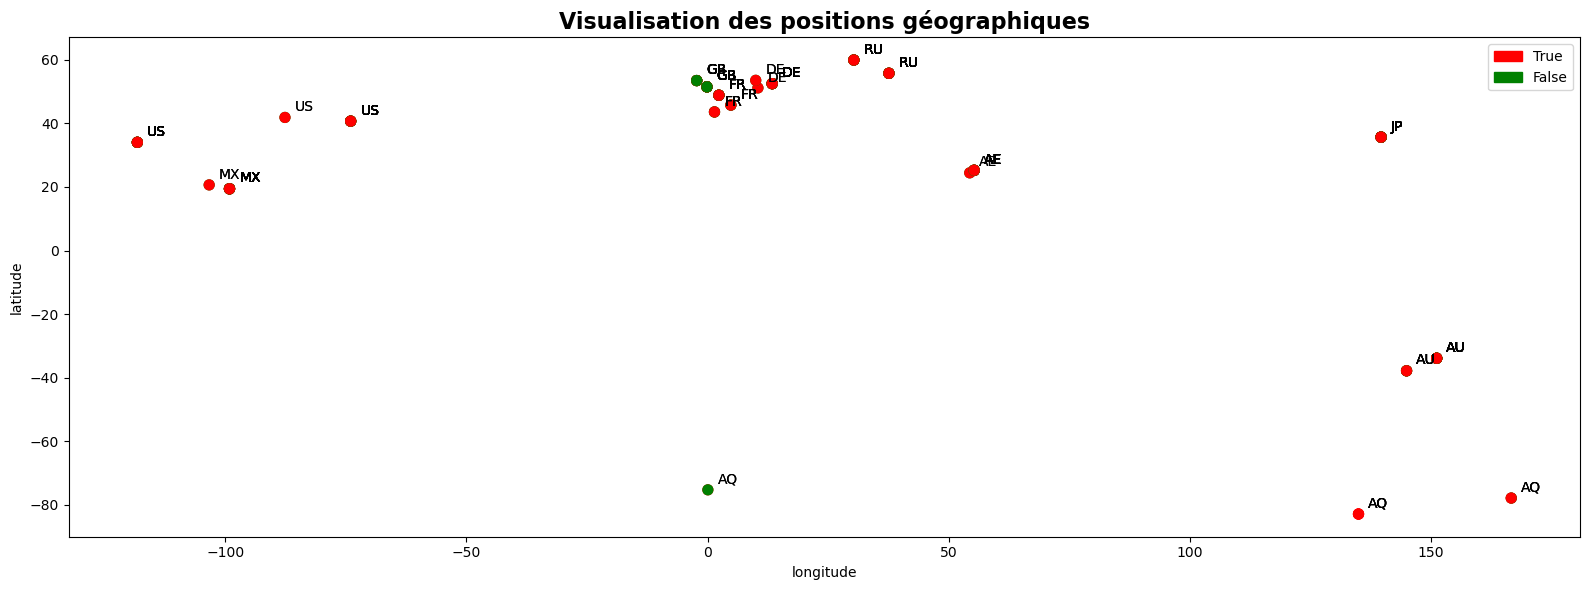

In [17]:
fig, ax = plt.subplots(figsize=(16,6))

colors = dt["alert_flag"].map({True: "red", False: "green"})

scatter = ax.scatter(
    dt["location_longitude"],
    dt["location_latitude"],
    c=colors,
    s=50
)

for i in range(len(dt)):
    ax.text(
        dt.loc[i,'location_longitude'] + 2,
        dt.loc[i,'location_latitude'] + 2,
        dt.loc[i,'address_country']
    )

# utiliser une légende au lieu de colorbar
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='red', label='True')
green_patch = mpatches.Patch(color='green', label='False')
ax.legend(handles=[red_patch, green_patch])

ax.set_title("Visualisation des positions géographiques", fontsize=16, fontweight="bold")
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')

plt.tight_layout()
plt.show()

Interprétation :

Les alertes sont réparties sur l’ensemble des régions du monde (Amérique, Europe, Asie, Australie, ).

On note une concentration d’alertes dans certaines zones, par exemple aux États-Unis, en Europe de l’Ouest et au Japon.

Les points verts sont également présents partout, mais certaines régions (ex. Russie, Mexique) semblent avoir proportionnellement plus d’alertes.

Conclusion : Les ruptures de chaîne du froid ne sont pas confinées à une zone géographique particulière, mais certaines régions semblent plus à risque.

In [18]:
taill=dt.groupby('address_city')['alert_flag'].value_counts()

In [19]:
dt['alert_flag']=dt['alert_flag'].astype('category')
dt['alert_flag']=dt['alert_flag'].cat.codes

In [20]:
dt['alert_flag']

0      0
1      1
2      0
3      1
4      0
      ..
195    1
196    0
197    1
198    0
199    1
Name: alert_flag, Length: 200, dtype: int8

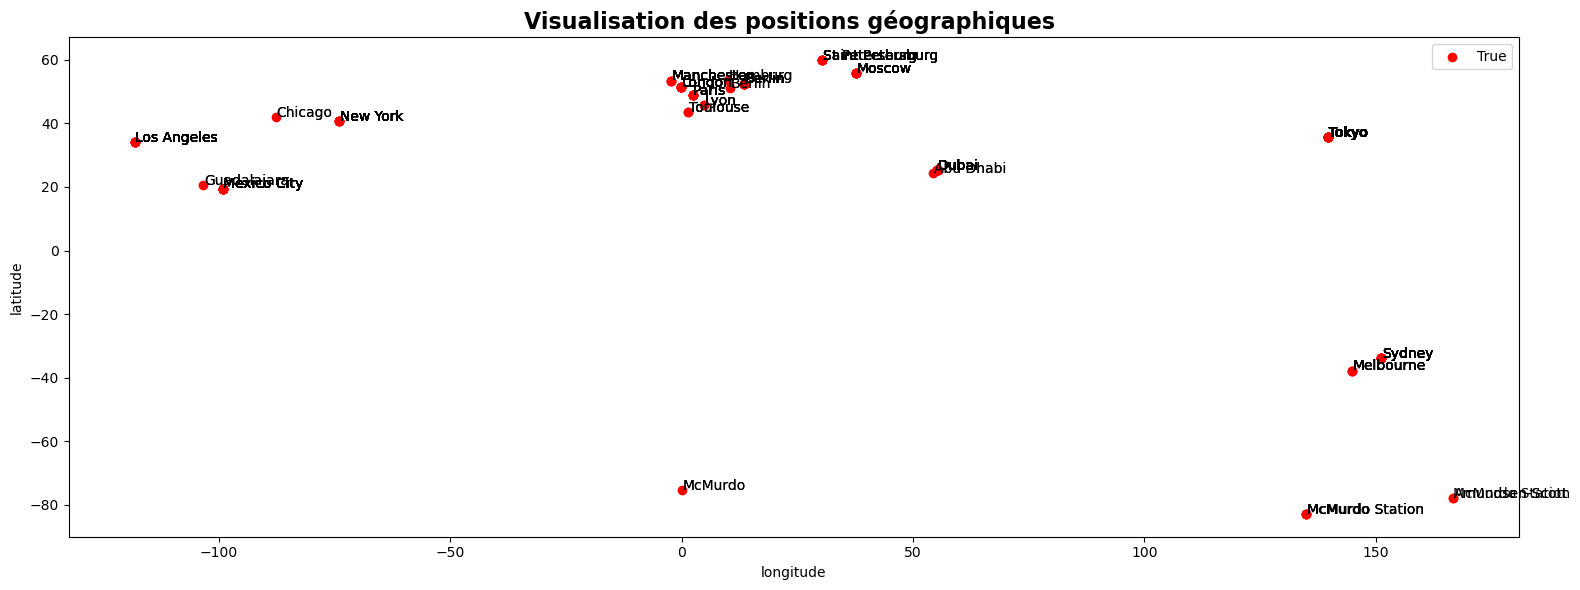

In [29]:

import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(16,6))
# créer une colonne couleur
taill=dt.groupby('address_city')['alert_flag'].value_counts()
dt_true = dt[dt["alert_flag"] == True]
dt_false = dt[dt["alert_flag"] == False]

# Scatter
ax.scatter(dt_true["location_longitude"], dt_true["location_latitude"],
           color="red",label="True")



for i in range(len(dt)):
        ax.text(
        dt.loc[i,'location_longitude']+0.1,
        dt.loc[i,'location_latitude']+0.1,
        dt.loc[i,'address_city']
    )


ax.set_title("Visualisation des positions géographiques ", fontsize=16, fontweight="bold")
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
ax.legend()
plt.tight_layout()
plt.show()

Interprétation :

Les villes comme Berlin, New York, Tokyo, Londres, Paris, Moscou, Sydney, Mexico, Dubaï apparaissent avec plusieurs points.

On observe que certaines villes ( Berlin, New York, Tokyo) présentent à la fois des points verts et rouges, ce qui indique que dans une même ville, certains envois sont conformes et d’autres non.

Des villes comme McMurdo (Antarctique) ou Amundsen‑Scott ont des alertes uniquement (rouge) – probablement dues aux conditions extrêmes.

Conclusion : La localisation seule ne détermine pas entièrement l’alerte ; d’autres facteurs (type de produit, opérateur, etc.) jouent un rôle majeur.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11952\3052608816.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


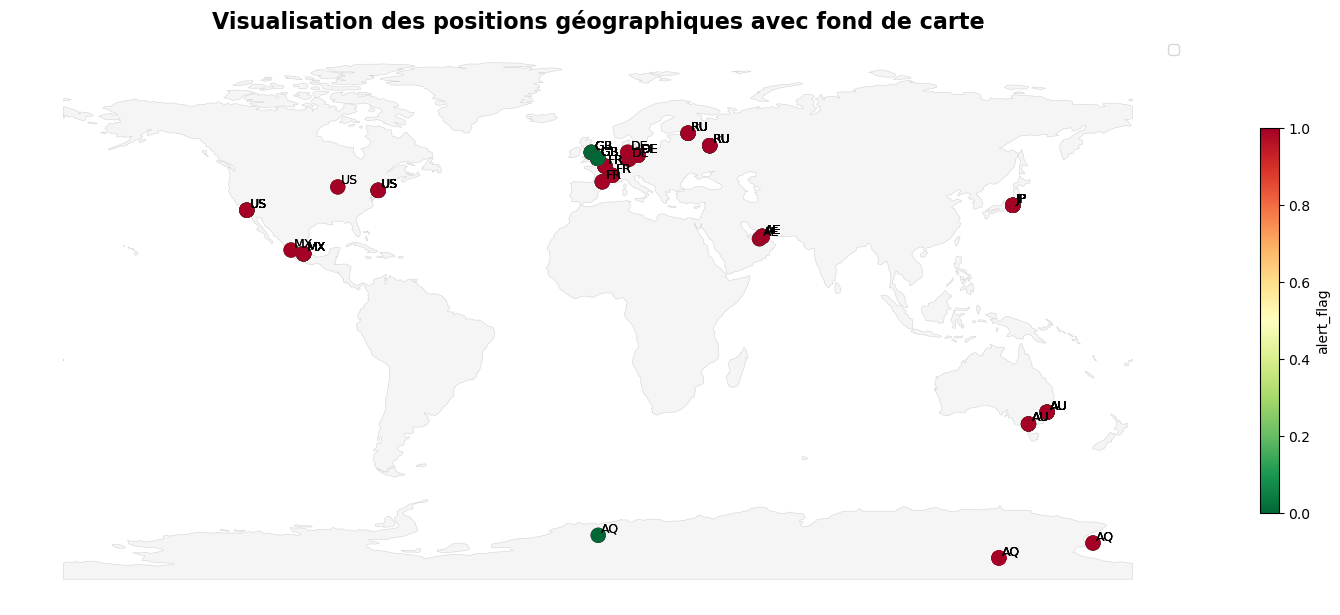

In [30]:
#Conversion en GeoDataFrame
import geopandas as gpd
import geodatasets
gdf = gpd.GeoDataFrame(
    dt,
    geometry=gpd.points_from_xy(dt["location_longitude"],dt["location_latitude"]),
    crs="EPSG:4326"
)
#Chargement du fond de carte
world = gpd.read_file(geodatasets.get_path("naturalearth.land"))

#Visualisation avec fond de carte
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# fond de carte
world.plot(
    ax=ax,
    color="whitesmoke",
    edgecolor="lightgray",
    linewidth=0.4
)

# points
scatter = ax.scatter(
    gdf["location_longitude"], gdf["location_latitude"], c=gdf["alert_flag"],
    s=100,
    cmap="RdYlGn_r" )

# noms des villes
for i in range(len(gdf)):
    ax.text(
        gdf.loc[i, "location_longitude"] +1,
        gdf.loc[i, "location_latitude"] + 1,
        gdf.loc[i, "address_country"],
        fontsize=9
    )

# barre de couleur
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
cbar.set_label("alert_flag")

ax.set_title("Visualisation des positions géographiques avec fond de carte", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.legend()
plt.show()

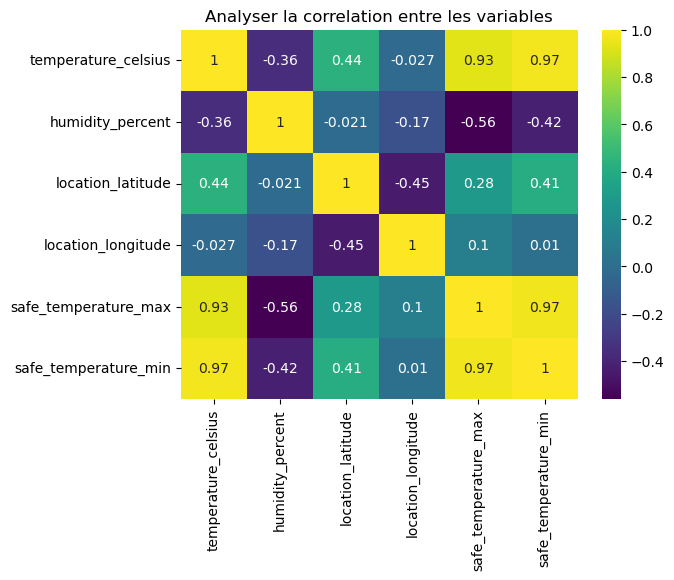

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
corr=dt[['temperature_celsius','humidity_percent','location_latitude','location_longitude',
                      'safe_temperature_max' ,'safe_temperature_min']].corr()
sns.heatmap(data=corr,cmap='viridis',annot=True)
plt.title('Analyser la correlation entre les variables')
plt.show()

Interprétation :

temperature_celsius est très fortement corrélée avec safe_temperature_max (proche de 1) et avec safe_temperature_min (également élevée). C’est normal car les seuils de sécurité dépendent du type de produit.

latitude et longitude sont faiblement corrélées avec les autres variables, confirmant que la géographie seule n’explique pas les dépassements.

L’humidité présente des corrélations très faibles avec toutes les autres variables.

Conclusion : La température relevée est le principal indicateur de dépassement des seuils de sécurité, ce qui est attendu. L’emplacement géographique n’a qu’un effet indirect.

In [33]:
dt['log_timestamp']

0       2024-05-01T09:15:00
1       2024-05-01T13:15:00
2       2024-05-02T11:10:00
3       2024-05-02T15:10:00
4       2024-05-03T10:20:00
               ...         
195    2024-04-23T12:45:00Z
196    2024-04-24T09:40:00Z
197    2024-04-24T13:25:00Z
198    2024-04-25T08:00:00Z
199    2024-04-25T12:30:00Z
Name: log_timestamp, Length: 200, dtype: str

In [34]:
dt.isnull().sum()

log_id                    0
shipment_id               0
container_id              0
product_type              0
sensor_id                 0
temperature_celsius       0
humidity_percent          0
log_timestamp             0
location_latitude         0
location_longitude        0
address_street            9
address_city              0
address_state             8
address_postal_code       9
address_country           0
is_within_safe_range      0
safe_temperature_min      0
safe_temperature_max      0
alert_flag                0
operator_id               0
date                    110
dtype: int64

pour ce projet on s'interesse aux colonnes 'is-within-safe-range' et 'alerte_flag',qui nous informons sur la qualite du produit et est-qui-il y a une detection d'un probleme lors du transportation

In [35]:
dt['shipment_id'].unique()


<ArrowStringArray>
[ 'SHIPA1',  'SHIPB2',  'SHIPC3',  'SHIPD4',  'SHIPE5',  'SHIPF6',  'SHIPG7',
  'SHIPH8',  'SHIPI9', 'SHIPJ10', 'SHIPA11', 'SHIPB12', 'SHIPC13', 'SHIPD14',
 'SHIPE15', 'SHIPF16', 'SHIPG17', 'SHIPH18', 'SHIPI19', 'SHIPJ20', 'SHIPA21',
 'SHIPB22', 'SHIPC23', 'SHIPD24', 'SHIPE25',  'SHIPB1',  'SHIPB3',  'SHIPB4',
  'SHIPB5',  'SHIPB6',  'SHIPB7',  'SHIPB8',  'SHIPB9',  'SHIPC1',  'SHIPC2',
  'SHIPC4',  'SHIPC5',  'SHIPC6',  'SHIPC7',  'SHIPC8',  'SHIPC9',  'SHIPD1',
  'SHIPD2',  'SHIPM1',  'SHIPP1',  'SHIPS1',  'SHIPF1', 'SHIPFL1',  'SHIPV1',
  'SHIPE1',  'SHIPI1',  'SHIPM2',  'SHIPP2',  'SHIPS2',  'SHIPF2', 'SHIPFL2',
  'SHIPV2',  'SHIPE2',  'SHIPI2',  'SHIPA7',  'SHIPG8',  'SHIPH1',  'SHIPJ2',
  'SHIPK3',  'SHIPL4',  'SHIPM5',  'SHIPN6',  'SHIPO7',  'SHIPP8',  'SHIPQ9',
  'SHIPR2',  'SHIPS3',  'SHIPT4',  'SHIPJ0',  'SHIPK1',  'SHIPL2',  'SHIPM3',
  'SHIPN4',  'SHIPO5']
Length: 79, dtype: str

In [36]:
dt['operator_id'].unique()


<ArrowStringArray>
['OP-DE001', 'OP-US002', 'OP-JP001', 'OP-RU001', 'OP-AU001', 'OP-FR001',
 'OP-GB001', 'OP-MX001', 'OP-AQ001', 'OP-AE001', 'OP-DE002', 'OP-US003',
 'OP-JP002', 'OP-RU002', 'OP-AU002', 'OP-FR002', 'OP-GB002', 'OP-MX002',
 'OP-AQ002', 'OP-AE002', 'OP-DE003', 'OP-US004', 'OP-JP003', 'OP-RU003',
 'OP-AU003', 'OP-DE021', 'OP-US102', 'OP-JP012', 'OP-RU101', 'OP-FR011',
 'OP-GB008', 'OP-MX007', 'OP-AE005', 'OP-US103', 'OP-RU102', 'OP-AU004',
 'OP-FR012', 'OP-GB009', 'OP-MX008', 'OP-AE006', 'OP-DE301', 'OP-US421',
 'OP-JP202', 'OP-RU581', 'OP-AU415', 'OP-FR206', 'OP-GB185', 'OP-MX372',
 'OP-AE563', 'OP-AQ011', 'OP-DE302', 'OP-US422', 'OP-JP203', 'OP-RU582',
 'OP-AU416', 'OP-FR207', 'OP-GB186', 'OP-MX373', 'OP-AE564', 'OP-AQ012',
 'OP-DE471', 'OP-US213', 'OP-JP008', 'OP-RU501', 'OP-AU204', 'OP-FR312',
 'OP-GB007', 'OP-MX009', 'OP-DE472', 'OP-US214', 'OP-JP009', 'OP-RU502',
 'OP-AU205', 'OP-FR313', 'OP-MX010', 'OP-DE101', 'OP-US202', 'OP-JP303',
 'OP-RU404', 'OP-AU505', 'OP-FR6

In [37]:
dt['container_id'].unique()

<ArrowStringArray>
['CONT01', 'CONT02', 'CONT03', 'CONT04', 'CONT05', 'CONT06', 'CONT07',
 'CONT08', 'CONT09', 'CONT10', 'CONT11', 'CONT12', 'CONT13', 'CONT14',
 'CONT15', 'CONT16', 'CONT17', 'CONT18', 'CONT19', 'CONT20', 'CONT21',
 'CONT22', 'CONT23', 'CONT24', 'CONT25', 'CONT26', 'CONT27', 'CONT28',
 'CONT29', 'CONT30', 'CONT35', 'CONT41', 'CONT53', 'CONT63', 'CONT71',
 'CONT82', 'CONT93', 'CONT34', 'CONT36', 'CONT45', 'CONT54', 'CONT64',
 'CONT72', 'CONT83']
Length: 44, dtype: str

Quels produits sont les plus sujets aux ruptures de cold chain ?

In [38]:
alert_flag_true=dt[dt['alert_flag']==1]
product_counts = alert_flag_true["product_type"].value_counts().reset_index()
print(product_counts)

      product_type  count
0            dairy     11
1             meat     11
2  pharmaceuticals     11
3          seafood     11
4            fruit     10
5          flowers     10
6         vaccines     10
7             eggs      9
8        chocolate      9
9        ice cream      7


<Figure size 1500x600 with 0 Axes>

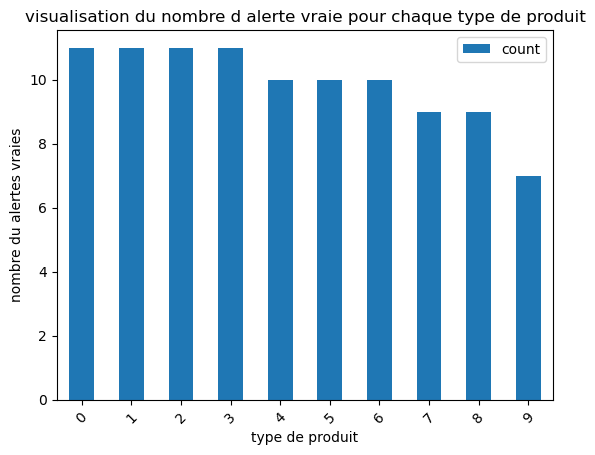

In [39]:
plt.figure(figsize=(15,6))
product_counts.plot(kind='bar')
plt.xticks(rotation=45)
plt.title("visualisation du nombre d alerte vraie pour chaque type de produit")
plt.xlabel("type de produit")
plt.ylabel('nombre du alertes vraies')
plt.show()

Description : Diagramme en barres montrant le nombre d’alertes (alert_flag = True) pour chaque catégorie de produit (product_type).

Interprétation :

Les produits dairy (produits laitiers), meat (viande), pharmaceuticals (médicaments), seafood (produits de la mer) totalisent chacun 11 alerts.

Fruit, flowers (fleurs), vaccins enregistrent 10 alertes chacun.

Les eggs (œufs) et chocolate (chocolat) ont 9 alertes, et ice cream (crème glacée) 7.

Observation : Les catégories les plus sensibles à la température (produits frais, médicaments, vaccins) ne sont pas nécessairement celles avec le plus d’alertes ; le nombre d’alertes semble surtout lié à la fréquence d’apparition de chaque produit dans le dataset (les catégories qui apparaissent le plus souvent ont plus d’alertes).

Cependant, les produits très périssables (viande, lait, fruits de mer) sont effectivement parmi les plus représentés.

Conclusion : Tous les produits sont exposés à des ruptures, mais une analyse plus fine (taux d’alerte = alertes / nombre total d’envois) serait plus pertinente pour comparer la criticité

In [40]:
import pandas as pd

product_city = alert_flag_true.groupby(["product_type", "address_city"]).size().reset_index(name="count")

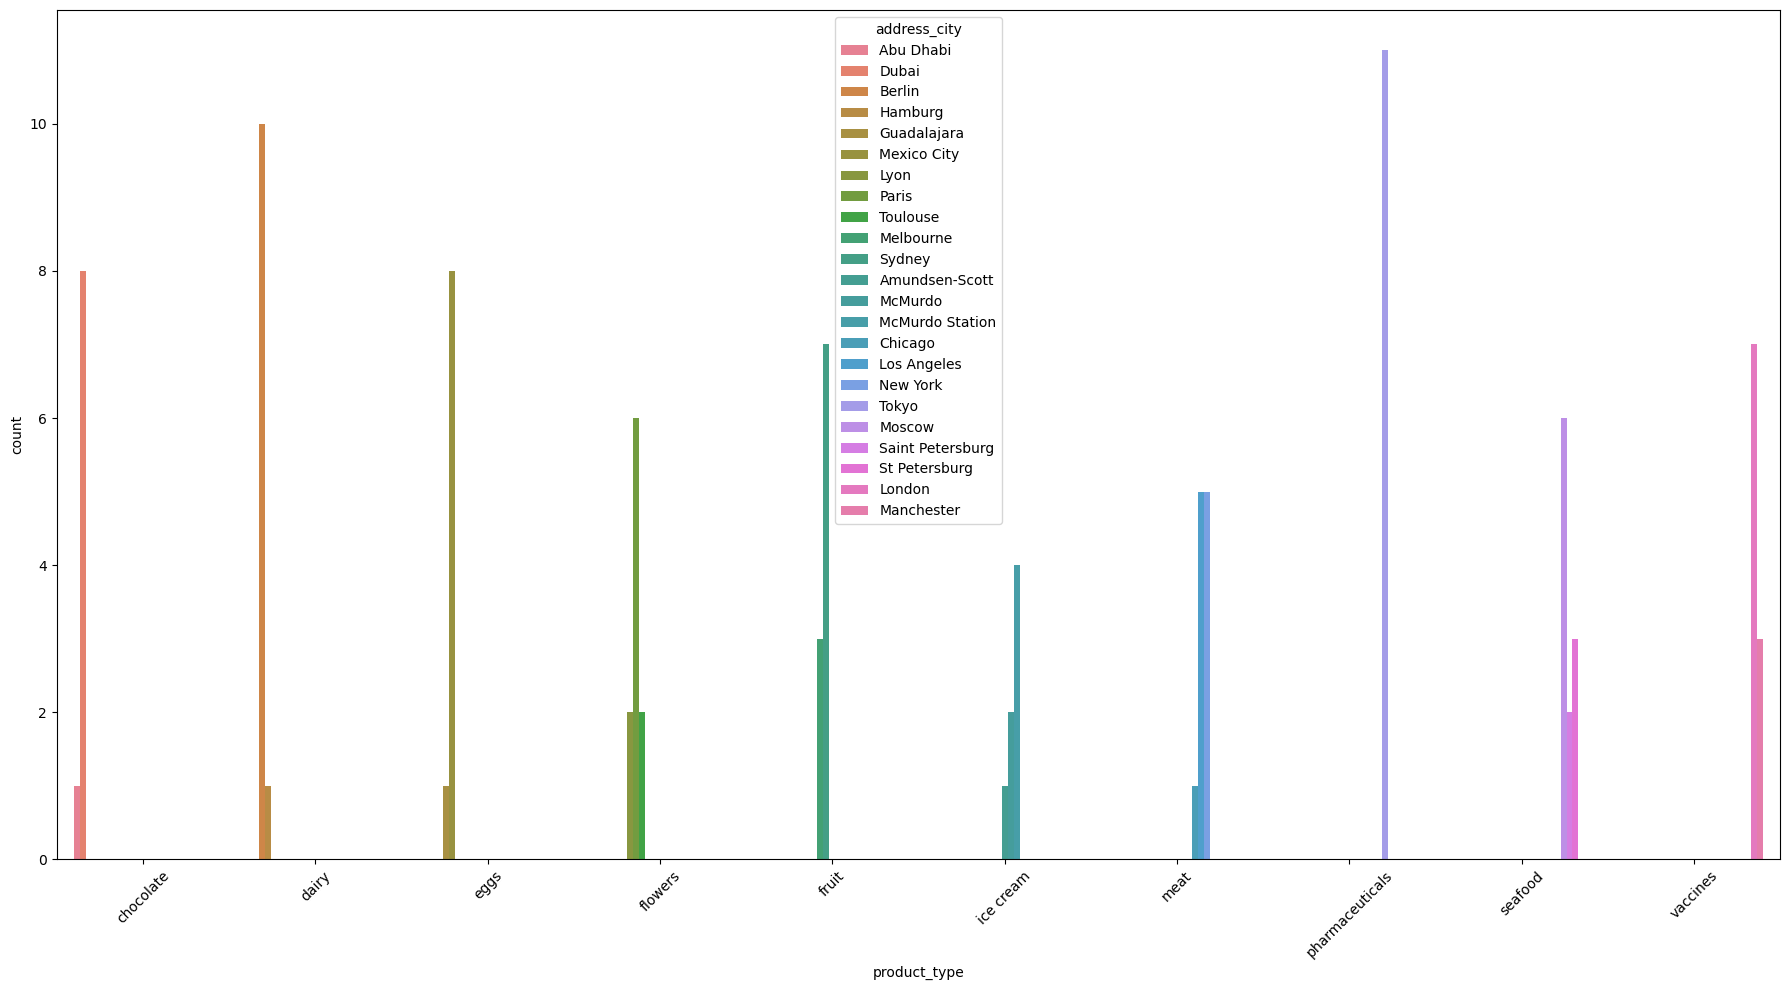

In [41]:
plt.figure(figsize=(18,10))
import seaborn as sns
sns.barplot(
    data=product_city,
    x='product_type',hue='address_city',y='count',palette=(sns.color_palette("husl", n_colors=product_city["address_city"].nunique())
))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interprétation :

Pour chaque type de produit, on voit quelles villes concentrent les alertes. Par exemple, les alertes pour dairy sont réparties entre plusieurs villes, mais certaines (comme Berlin, New York) apparaissent plus souvent.

pharmaceuticals et vaccines montrent des alertes dans des villes très diverses (Tokyo, New York, Londres, etc.), ce qui souligne que les médicaments et vaccins subissent des ruptures partout.

Les fleurs (flowers) ont des alertes surtout dans des villes comme Amsterdam (?), Berlin, etc. – cohérent avec les hubs de transport de fleurs.

Conclusion : La combinaison produit‑ville permet d’identifier des corridors à risque. Par exemple, les produits laitiers en provenance de certaines villes semblent plus vulnérables.

KPI

In [42]:
score=dt['alert_flag'].mean()

In [43]:
score

np.float64(0.495)

In [44]:
risk = dt.groupby("product_type")["alert_flag"].mean()
dt["risk_score"] = dt["product_type"].map(risk)

In [45]:
dt['risk_score']

0      0.5
1      0.5
2      0.5
3      0.5
4      0.5
      ... 
195    0.5
196    0.5
197    0.5
198    0.5
199    0.5
Name: risk_score, Length: 200, dtype: float64

C. Analyse géospatiale

In [46]:
from sklearn.cluster import KMeans

coords = dt[["location_longitude", "location_latitude"]]
dt["cluster"] = KMeans(n_clusters=5).fit_predict(coords)

c:\Users\Lenovo\miniconda3\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\Lenovo\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


détecte zones à risque sans villes

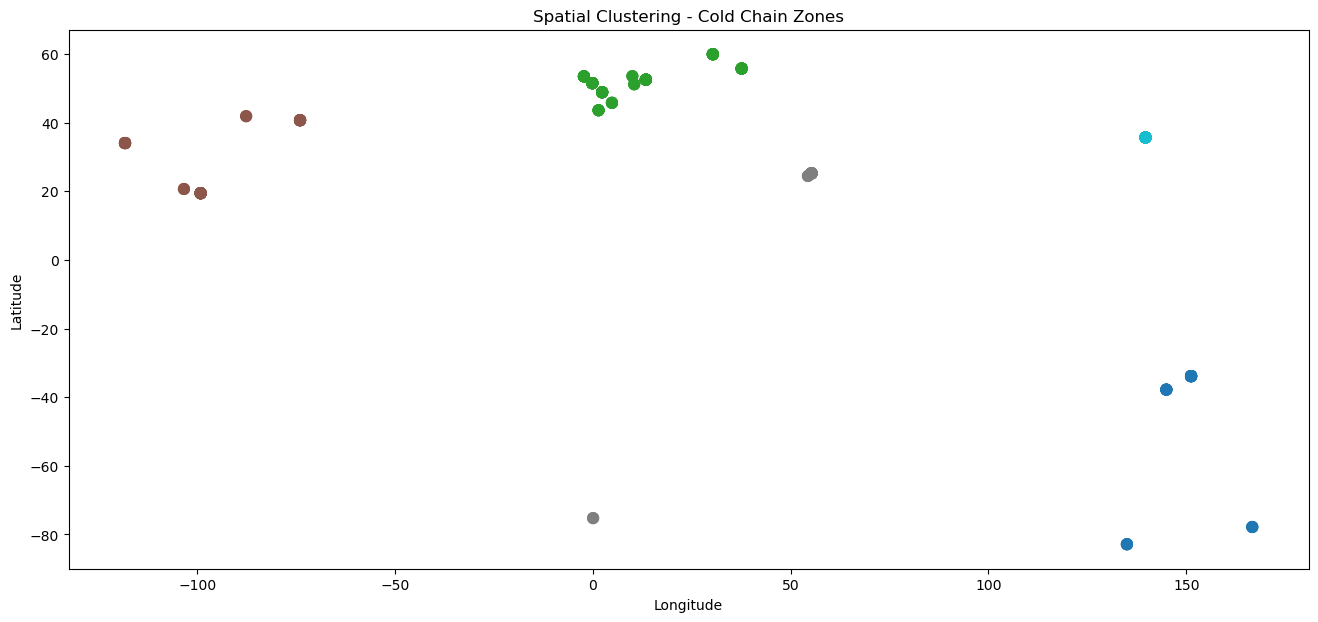

In [47]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16,7))

scatter = ax.scatter(
    dt["location_longitude"],
    dt["location_latitude"],
    c=dt["cluster"],
    cmap="tab10",
    s=60
)

ax.set_title("Spatial Clustering - Cold Chain Zones")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

Description : Nuage de points où la couleur indique le cluster attribué par l’algorithme K‑means (5 clusters) sur les coordonnées longitude/latitude. Les regroupements sont purement géographiques.

Interprétation :

Les 5 clusters correspondent à des grandes zones : Amérique du Nord, Europe, Asie de l’Est, Australie, et une zone mêlant Moyen‑Orient/Afrique/Amérique latine.

Les points d’un même cluster sont géographiquement proches. Cela permet de segmenter les itinéraires.

Utilité : On pourra ensuite analyser le taux d’alerte par cluster pour savoir quelles zones géographiques présentent le plus de risques, indépendamment des villes.

Chaque couleur = une zone géographique détectée automatiquement

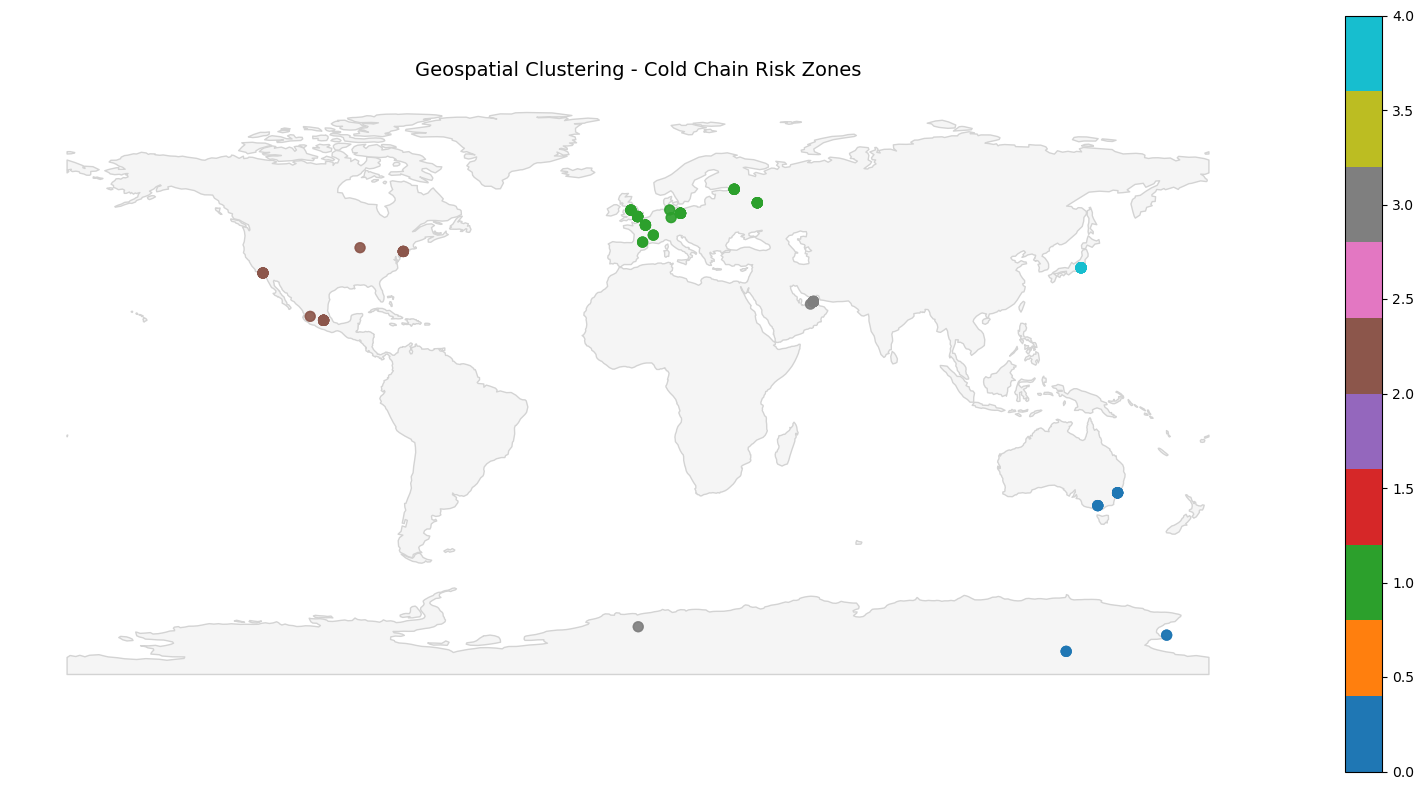

In [48]:
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import geodatasets




gdf = gpd.GeoDataFrame(
    dt,
    geometry=gpd.points_from_xy(dt["location_longitude"], dt["location_latitude"]),
    crs="EPSG:4326"
)

world = gpd.read_file(geodatasets.get_path("naturalearth.land"))


fig, ax = plt.subplots(figsize=(16,8))

world.plot(
    ax=ax,
    color="whitesmoke",
    edgecolor="lightgray"
)

# . clusters
gdf.plot(
    ax=ax,
    column="cluster",
    cmap="tab10",
    markersize=50,
    alpha=0.7,
    legend=True
)


ax.set_title("Geospatial Clustering - Cold Chain Risk Zones", fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.show()

Description : Carte du monde avec les mêmes points colorés par cluster (K‑means). Le fond de carte (continents) aide à visualiser la répartition géographique réelle.

Interprétation :

Les clusters sont bien séparés : un cluster pour l’Europe (principalement France, Allemagne, Royaume‑Uni), un pour l’Amérique du Nord (USA, Mexique), un pour l’Asie (Japon, Dubaï, Inde ?), un pour l’Océanie (Australie), et un pour l’Antarctique (stations polaires).

On remarque que les points en Antarctique (McMurdo, Amundsen‑Scott) sont dans un cluster distinct, logique vu l’isolement géographique et les conditions climatiques extrêmes.

Conclusion : Le clustering géographique peut servir à personnaliser les stratégies de monitoring : chaque zone peut avoir des causes d’alertes différentes (climat, infrastructure, distance)

Synthèse générale des tendances observées
Les alertes sont fréquentes : environ 49,5 % des enregistrements déclenchent une alerte (moyenne de alert_flag). C’est un taux élevé, indiquant des problèmes récurrents dans la chaîne du froid.

Les produits les plus concernés (en nombre absolu) sont les produits laitiers, la viande, les médicaments, les fruits de mer. Mais une analyse en proportion serait nécessaire.

L’impact géographique : Certaines régions (Europe, Amérique du Nord) présentent un grand nombre d’alertes, mais aussi beaucoup d’envois. Des zones polaires semblent très critiques (100% d’alertes).

La température est le facteur le plus corrélé aux dépassements de seuils.

Les clusters géographiques identifiés permettront d’affiner l’analyse des risques par zone et d’adapter les mesures correctives (renforcement des conteneurs, choix des transporteurs, amélioration des itinéraires).

Ces interprétations aident à comprendre les principales causes des ruptures de chaîne du froid et à orienter les actions d’amélioration.